Dataset shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


<Figure size 1200x1000 with 0 Axes>

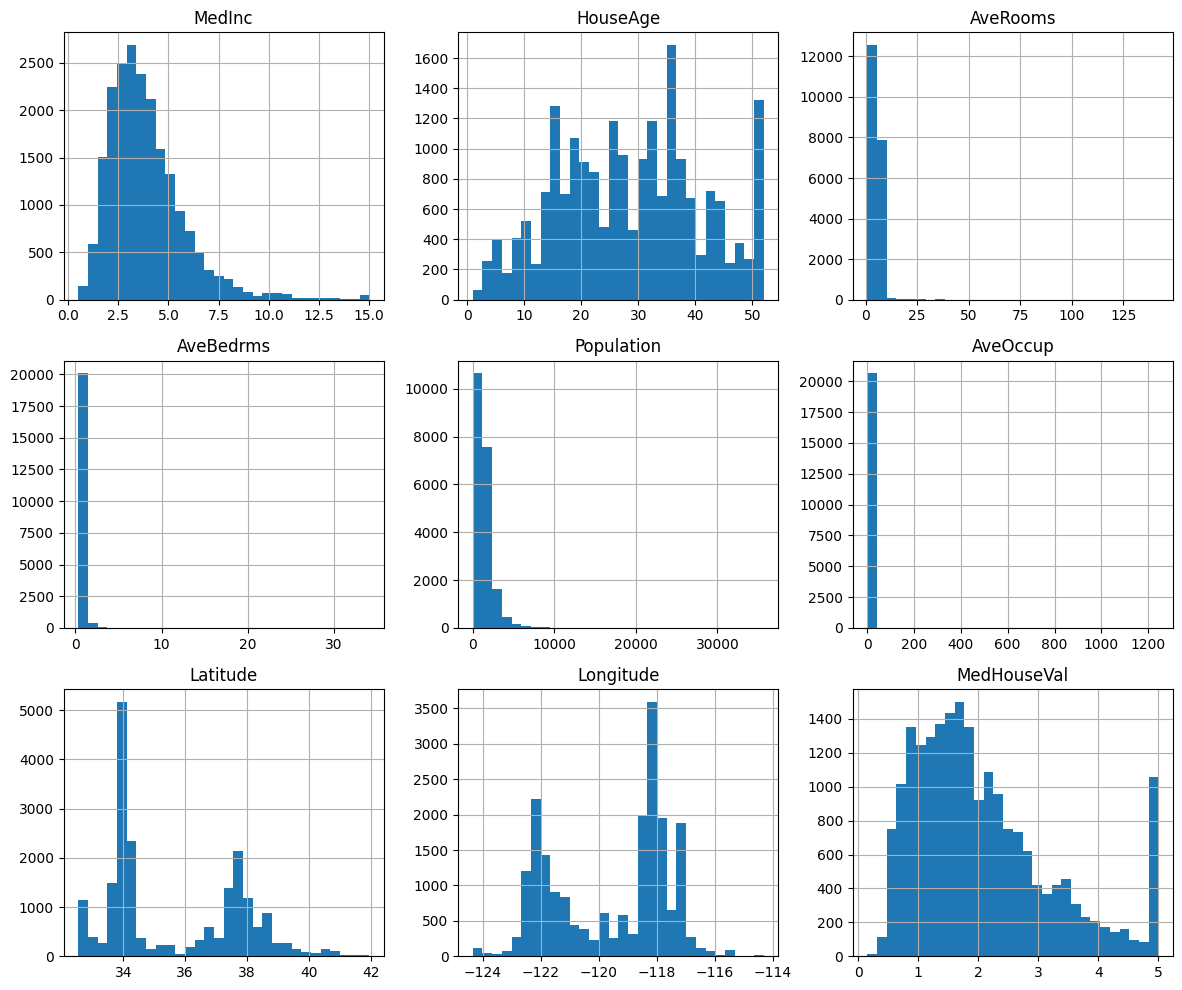

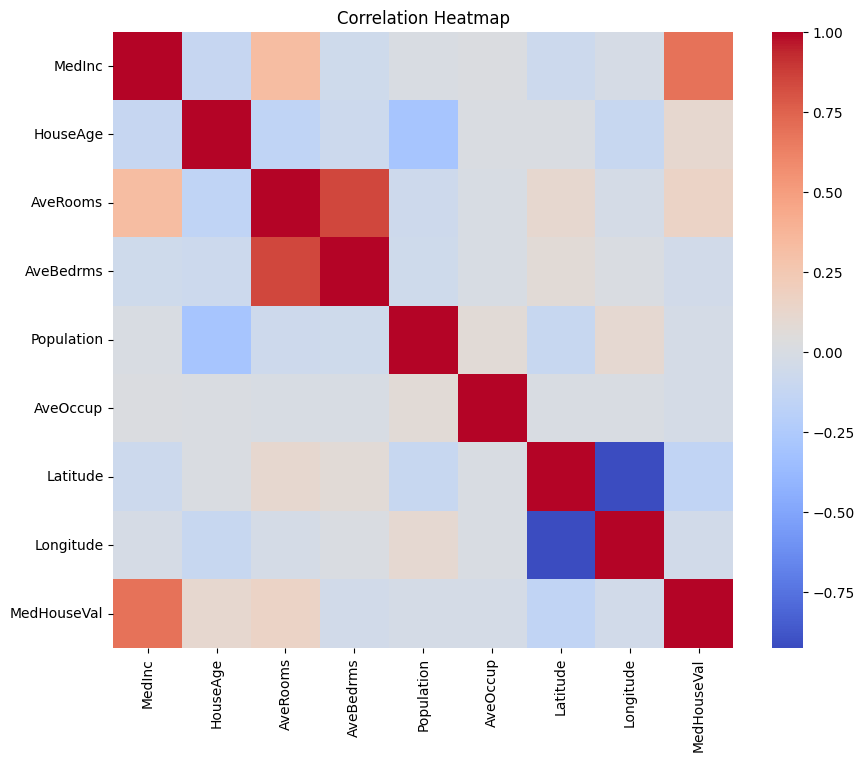


Summary statistics:
               count         mean          std         min         25%  \
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000   
AveRooms     20640.0     5.429000     2.474173    0.846154    4.440716   
AveBedrms    20640.0     1.096675     0.473911    0.333333    1.006079   
Population   20640.0  1425.476744  1132.462122    3.000000  787.000000   
AveOccup     20640.0     3.070655    10.386050    0.692308    2.429741   
Latitude     20640.0    35.631861     2.135952   32.540000   33.930000   
Longitude    20640.0  -119.569704     2.003532 -124.350000 -121.800000   
MedHouseVal  20640.0     2.068558     1.153956    0.149990    1.196000   

                     50%          75%           max  
MedInc          3.534800     4.743250     15.000100  
HouseAge       29.000000    37.000000     52.000000  
AveRooms        5.229129     6.052381    141.909091  
AveBedrms       1.0487

In [ ]:
# ✅ CLEAN, ERROR-FREE FULL MACHINE LEARNING PROJECT (CALIFORNIA HOUSING)
# ---------------------------------------------------------------
# Includes:
# - Data loading
# - EDA + graphs
# - Data cleaning
# - Feature engineering
# - Pipelines
# - Model training & CV
# - Hyperparameter tuning
# - Evaluation + plots
# ---------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

RANDOM_STATE = 42

# ---------------------------------------------------------------
# 1) LOAD DATASET
# ---------------------------------------------------------------
cal = fetch_california_housing(as_frame=True)
df = cal.frame.copy()
print("Dataset shape:", df.shape)
print(df.head())

# ---------------------------------------------------------------
# 2) EDA + VISUALIZATIONS
# ---------------------------------------------------------------
plt.figure(figsize=(12,10))
df.hist(bins=30, figsize=(12,10))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("\nSummary statistics:")
print(df.describe().T)

# ---------------------------------------------------------------
# 3) DATA CLEANING
# ---------------------------------------------------------------
print("\nMissing values per column:")
print(df.isnull().sum())

numeric_cols = df.columns.drop('MedHouseVal')
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5*IQR)) | (df[numeric_cols] > (Q3 + 1.5*IQR))).sum()
print("\nOutlier counts per column:")
print(outliers)

# ---------------------------------------------------------------
# 4) FEATURE ENGINEERING
# ---------------------------------------------------------------
df_fe = df.copy()
eps = 1e-6
df_fe['rooms_per_person'] = df_fe['AveRooms'] / (df_fe['Population'] + eps)
df_fe['bedrooms_per_room'] = df_fe['AveBedrms'] / (df_fe['AveRooms'] + eps)

LAT0, LON0 = 36.7783, -119.4179
df_fe['sq_dist_center'] = (df_fe['Latitude'] - LAT0)**2 + (df_fe['Longitude'] - LON0)**2

print("\nNew engineered features:")
print(df_fe[['rooms_per_person','bedrooms_per_room','sq_dist_center']].head())

# ---------------------------------------------------------------
# 5) TRAIN-TEST SPLIT
# ---------------------------------------------------------------
X = df_fe.drop('MedHouseVal', axis=1)
y = df_fe['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# ---------------------------------------------------------------
# 6) PREPROCESSING + MODELS
# ---------------------------------------------------------------
numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features)
])

ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=RANDOM_STATE))
])

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

# ---------------------------------------------------------------
# 7) CROSS VALIDATION
# ---------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_rmse(pipe):
    scores = cross_val_score(pipe, X_train, y_train, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1)
    return np.sqrt(-scores)

for name, pipe in [('Ridge', ridge_pipe), ('RandomForest', rf_pipe), ('GBRT', gb_pipe)]:
    scores = cv_rmse(pipe)
    print(f"\n{name} CV RMSE: mean={scores.mean():.4f}, std={scores.std():.4f}")

# ---------------------------------------------------------------
# 8) HYPERPARAMETER TUNING
# ---------------------------------------------------------------
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__max_features': ['auto', 'sqrt']
}

gs = GridSearchCV(rf_pipe, param_grid, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("\nBest params:", gs.best_params_)
best_rf = gs.best_estimator_

# ---------------------------------------------------------------
# 9) TEST SET EVALUATION
# ---------------------------------------------------------------
models = {
    'BestRandomForest': best_rf,
    'GradientBoosting': gb_pipe,
    'Ridge': ridge_pipe
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds),
        'R2': r2_score(y_test, preds)
    }

print("\nTEST RESULTS:")
print(pd.DataFrame(results).T)

# ---------------------------------------------------------------
# 10) FEATURE IMPORTANCE + GRAPHS
# ---------------------------------------------------------------
preds = best_rf.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

plt.figure(figsize=(6,6))
residuals = y_test - preds
plt.scatter(preds, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(y_test, label='Actual')
sns.kdeplot(preds, label='Predicted')
plt.legend()
plt.title("Distribution: Actual vs Predicted")
plt.show()

rf_model = best_rf.named_steps['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=numeric_features).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.head(15).plot(kind='bar')
plt.title("Top Feature Importances (Random Forest)")
plt.show()

# ---------------------------------------------------------------
# 11) SAVE MODEL
# ---------------------------------------------------------------
joblib.dump(best_rf, 'best_random_forest_model.joblib')
print("\nModel saved successfully!")

print("\nSCRIPT COMPLETE ✓")